In [1]:
# Import Libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import lasio

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

## Loading and Visualizing LAS

In [3]:
# Check the wells and logs available in the LAS files
well_names = ["BLT-01", "JUT-01", "EVD-01", "PKP-01"]
dfs_las = {}

for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df().reset_index()

    dfs_las[well] = df_las

    print(f"\nWell Name: {well}")
    print("LAS DataFrame shape:", df_las.shape)
    print("Columns:", list(df_las.columns))
    df_las.head(8)


Well Name: BLT-01
LAS DataFrame shape: (27875, 20)
Columns: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']

Well Name: JUT-01
LAS DataFrame shape: (22427, 5)
Columns: ['DEPT:1', 'DEPT:2', 'GR', 'DT', 'RHOB']

Well Name: EVD-01
LAS DataFrame shape: (21569, 5)
Columns: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO']

Well Name: PKP-01
LAS DataFrame shape: (27508, 6)
Columns: ['DEPT', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


In [4]:
# Choose depth column in metres
depth_cols = ["MD", "DEPT:1", "DEPT:2", "DEPT"]

for well in well_names:
    las = lasio.read(f"{RAW}/{well}.las")
    md_m = None
    for c in depth_cols:
        
        if c not in dfs_las[well].columns:
            continue

        unit = None
        for curve in las.curves:
            if curve.mnemonic == c:
                unit = (curve.unit or "").upper()
                break

        if unit in ("M", "M "):
            md_m = dfs_las[well][c].values
            break

    if md_m is None:
        print(f"No metric depth found for {well}")
        continue

    dfs_las[well]["MD_m"] = md_m
    
    # Standardise sonic log column
    for col in ["DT", "DTC"]:
        if col in dfs_las[well].columns:
            dfs_las[well] = dfs_las[well].rename(columns={col: "DTC"})
            break

    dfs_las[well] = dfs_las[well].set_index("MD_m")

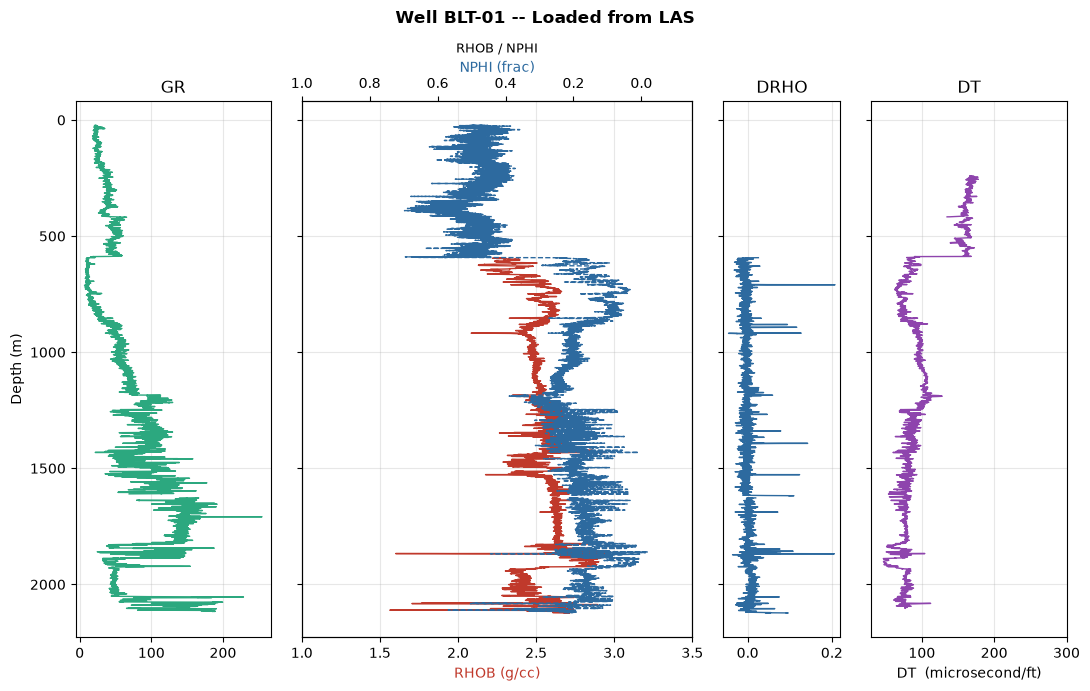

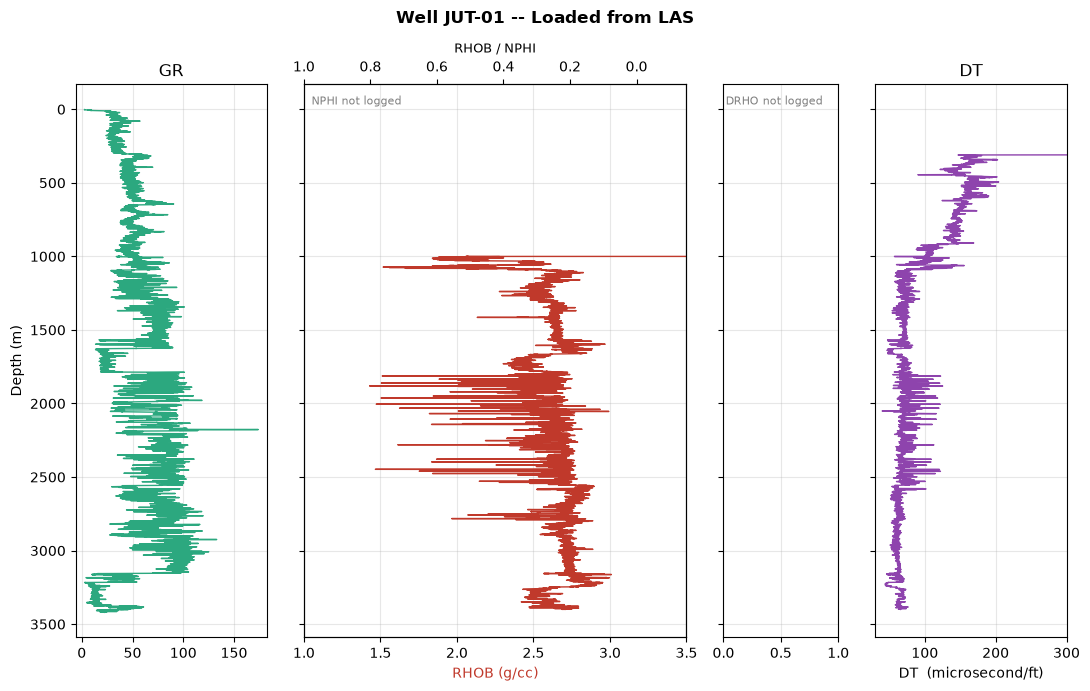

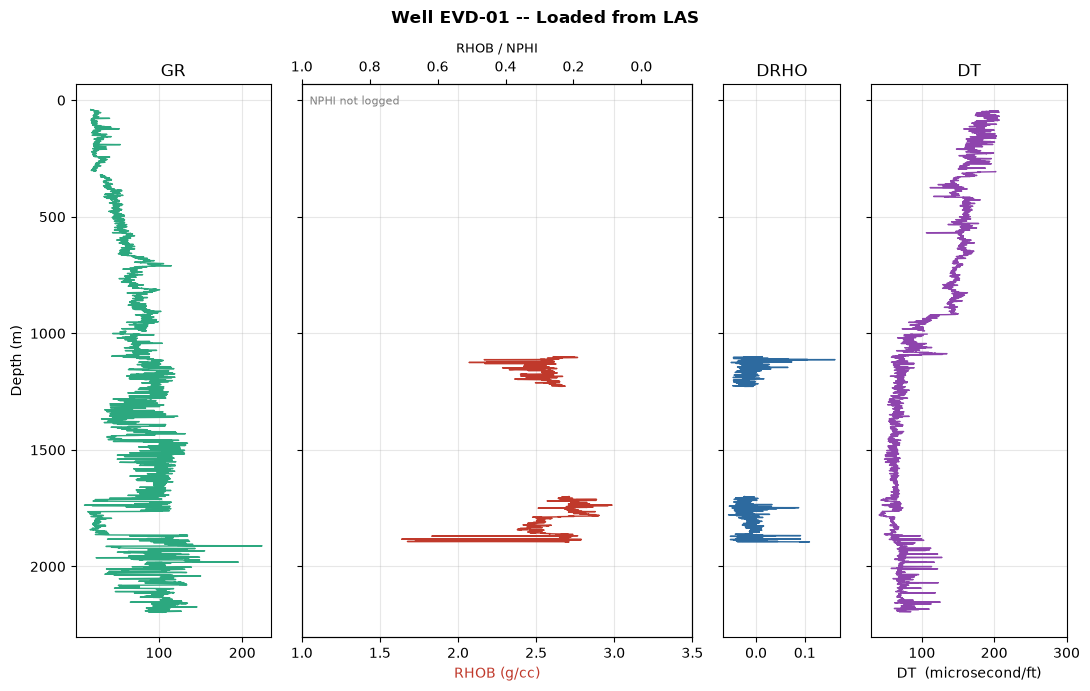

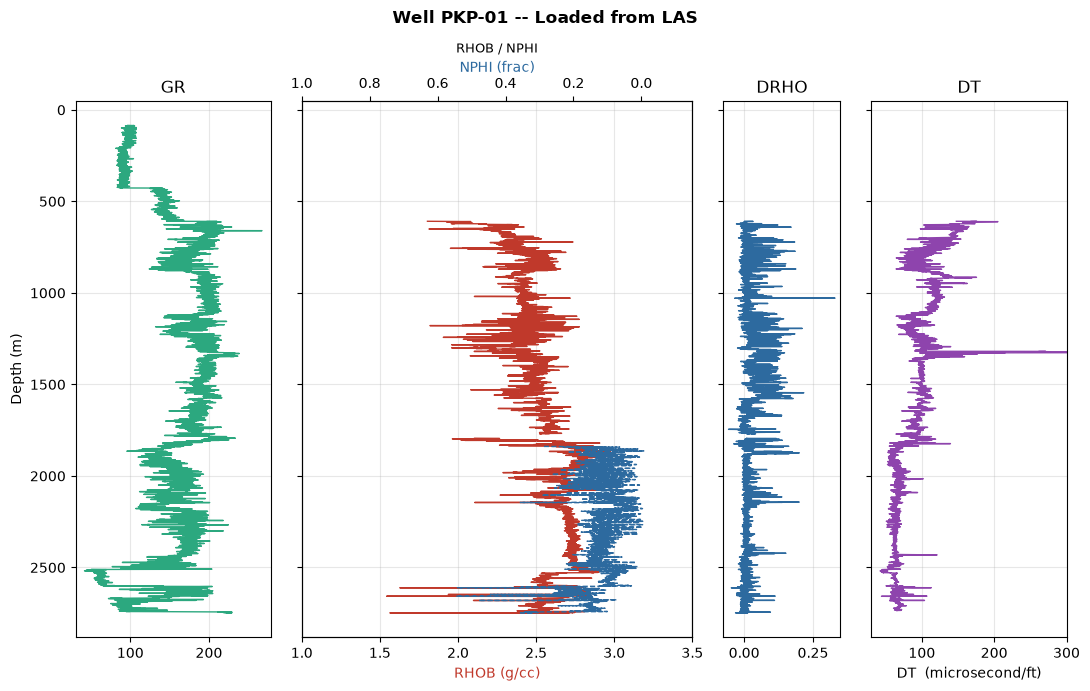

In [5]:
# GR, RHOB, NPHI, DRHO, DTC logs plotted
for well in well_names:
    df_las = dfs_las[well]

    depth_col = "MD_m"
    df_las_clean = df_las.reset_index().sort_values(depth_col)
    dfs_las[well] = df_las_clean

    fig, axes = plt.subplots(1, 4, figsize=(11, 7), sharey=True, gridspec_kw={"width_ratios": [1, 2, 0.6, 1]})
    fig.suptitle(f"Well {well} -- Loaded from LAS", fontsize=12, fontweight="bold")

    axes[0].plot(df_las_clean["GR"], df_las_clean[depth_col], color="#2ca87f", linewidth=1)
    axes[0].set_label("GR (API)") 
    axes[0].set_title("GR") 
    axes[0].invert_yaxis() 
    axes[0].set_ylabel("Depth (m)") 

    ax2a = axes[1]
    ax2b = ax2a.twiny()
    ax2a.plot(df_las_clean["RHOB"], df_las_clean[depth_col], color="#c0392b", linewidth=1, label="RHOB")
    ax2a.set_xlabel("RHOB (g/cc)", color="#c0392b")

    if "NPHI" in df_las_clean.columns:
        ax2b.plot(df_las_clean["NPHI"], df_las_clean[depth_col], color="#2d6a9f", linewidth=1, linestyle="--", label="NPHI")
        ax2b.set_xlabel("NPHI (frac)", color="#2d6a9f")
    else:
        ax2a.text(0.02, 0.98, "NPHI not logged", transform=ax2a.transAxes, va="top", fontsize=8, color="gray")
    axes[1].set_title("RHOB / NPHI", fontsize=9) 
    ax2a.set_xlim(1.0, 3.5)
    ax2b.set_xlim(1.0, -0.15)

    if "DRHO" in df_las_clean.columns:
        axes[2].plot(df_las_clean["DRHO"], df_las_clean[depth_col], color="#2d6a9f", linewidth=1)
        axes[2].set_label("DRHO  (g/cc)")
        axes[2].set_title("DRHO")
    else:
        axes[2].text(0.02, 0.98, "DRHO not logged", transform=axes[2].transAxes, va="top", fontsize=8, color="gray")

    if "DTC" in df_las_clean.columns:
        axes[3].plot(df_las_clean["DTC"], df_las_clean[depth_col], color="#8e44ad", linewidth=1)
        axes[3].set_xlabel("DT  (microsecond/ft)")
        axes[3].set_title("DT")
        axes[3].set_xlim(30, 300)

    for ax in axes: 
        ax.grid(True, alpha=0.3)

    plt.tight_layout() 
    plt.show()

## Loading CSV

In [6]:
# Load raw target lithologies data
raw_data = pd.read_csv(RAW / "target_lithologies.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                3455 non-null   str    
 1   easting                3455 non-null   float64
 2   northing               3455 non-null   float64
 3   depth_tvd_m            0 non-null      float64
 4   porosity_pct           2419 non-null   float64
 5   gamma_ray_api          3455 non-null   float64
 6   bulk_density_gcc       3199 non-null   float64
 7   formation_top_tvd      3455 non-null   float64
 8   formation_base_tvd     3455 non-null   float64
 9   formation_thickness_m  3455 non-null   float64
 10  distance_to_usp_km     3455 non-null   float64
 11  flag                   3455 non-null   str    
 12  flag_reason            3455 non-null   str    
dtypes: float64(10), str(3)
memory usage: 351.0 KB


## Checking 'well_id'

In [7]:
df = raw_data.copy() 
df['well_id'].value_counts()

well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64

## Checking empty rows

In [8]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


Missing depth_tvd_m counts per well:
well_id
BLT-01    1689
EVD-01     780
JUT-01     256
PKP-01     730
dtype: int64

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    256
dtype: int64

Missing bulk_density_gcc counts per well:
well_id
JUT-01    256
dtype: int64


### Filling in 'depth_tvd_m'

In [9]:
# Load Well Path Data
wp = {}

for well in well_names:
    wp[well] = pd.read_excel(RAW / "Well Path Data.xlsx", sheet_name=well)

    wp[well] = wp[well].rename(columns={
        "Depth (m)": "MD_m", "TVD (m)": "TVD_m",
        "Inclination (º)": "incl_deg", "Azimuth (º)": "azim_deg",
        "X-offset (m)": "x_offset_m", "Y-offset (m)": "y_offset_m"
    })

In [10]:
def recover_depth(well, target_rows, las_curves, well_path):
    top_depth = target_rows["formation_top_tvd"].iloc[0]
    bottom_depth = target_rows["formation_base_tvd"].iloc[0]

    gr = las_curves.dropna(subset=["GR", "MD_m"]).reset_index(drop=True)
    gr = gr[(gr["MD_m"] >= top_depth) & (gr["MD_m"] <= bottom_depth)].copy()

    survey_md = well_path["MD_m"].values
    survey_tvd = well_path["TVD_m"].values
    gr["depth_tvd_m"] = np.interp(gr["MD_m"], survey_md, survey_tvd)

    target_clean = target_rows.reset_index().drop(columns=["depth_tvd_m"])
    merged = target_clean.merge(
        gr[["GR", "depth_tvd_m"]].rename(columns={"GR": "gamma_ray_api"}),
        on="gamma_ray_api", how="left"
    ).drop_duplicates(subset="index").set_index("index")

    n_matched = merged["depth_tvd_m"].notna().sum()
    print(f"{well}: {n_matched} / {len(target_rows)} rows matched")
    df.loc[merged.index, "depth_tvd_m"] = merged["depth_tvd_m"]

In [11]:
def rebuild_jut01_rows(target_rows, las_curves, well_path):
    global df
    top_depth = target_rows["formation_top_tvd"].iloc[0]
    bottom_depth = target_rows["formation_base_tvd"].iloc[0]

    gr = las_curves.dropna(subset=["GR", "RHOB", "MD_m"]).reset_index(drop=True)
    gr = gr[(gr["MD_m"] >= top_depth) & (gr["MD_m"] <= bottom_depth)].copy()

    survey_md = well_path["MD_m"].values
    survey_tvd = well_path["TVD_m"].values
    gr["depth_tvd_m"] = np.interp(gr["MD_m"], survey_md, survey_tvd)

    new_rows = pd.DataFrame({
        "well_id": "JUT-01",
        "depth_tvd_m":        gr["depth_tvd_m"],
        "gamma_ray_api":      gr["GR"],
        "bulk_density_gcc":   gr["RHOB"],
        "formation_top_tvd":  top_depth,
        "formation_base_tvd": bottom_depth,
        "formation_thickness_m": 127.5,
    })
    for col in ["easting", "northing", "distance_to_usp_km"]:
        if col in target_rows.columns:
            new_rows[col] = target_rows[col].iloc[0]

    df = df[df["well_id"] != "JUT-01"]
    df = pd.concat([df, new_rows], ignore_index=True)
    print(f"JUT-01: replaced {len(target_rows)} wrong-window rows with {len(new_rows)} correct rows")

In [12]:
for well in well_names:
    target_rows = df[df["well_id"] == well]
    if well == "JUT-01":
        rebuild_jut01_rows(target_rows, dfs_las[well], wp[well])
    else:    
        recover_depth(well, target_rows, dfs_las[well], wp[well])

BLT-01: 1689 / 1689 rows matched
JUT-01: replaced 256 wrong-window rows with 836 correct rows
EVD-01: 780 / 780 rows matched
PKP-01: 730 / 730 rows matched


In [13]:
well_list = df['well_id'].unique().tolist()
print(f"\nThis  is a list of all the wells in target_lithologies.csv: {well_list}")
log_cols = ["porosity_pct", "gamma_ray_api", "bulk_density_gcc"]
print(f"\nThese are the log columns in target_lithologies.csv: {log_cols}")


This  is a list of all the wells in target_lithologies.csv: ['EVD-01', 'PKP-01', 'BLT-01', 'JUT-01']

These are the log columns in target_lithologies.csv: ['porosity_pct', 'gamma_ray_api', 'bulk_density_gcc']


## Log and Target CSV Overlay

C:\Users\sadar\AppData\Local\Temp\ipykernel_1840\3727583388.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\sadar\AppData\Local\Temp\ipykernel_1840\3727583388.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


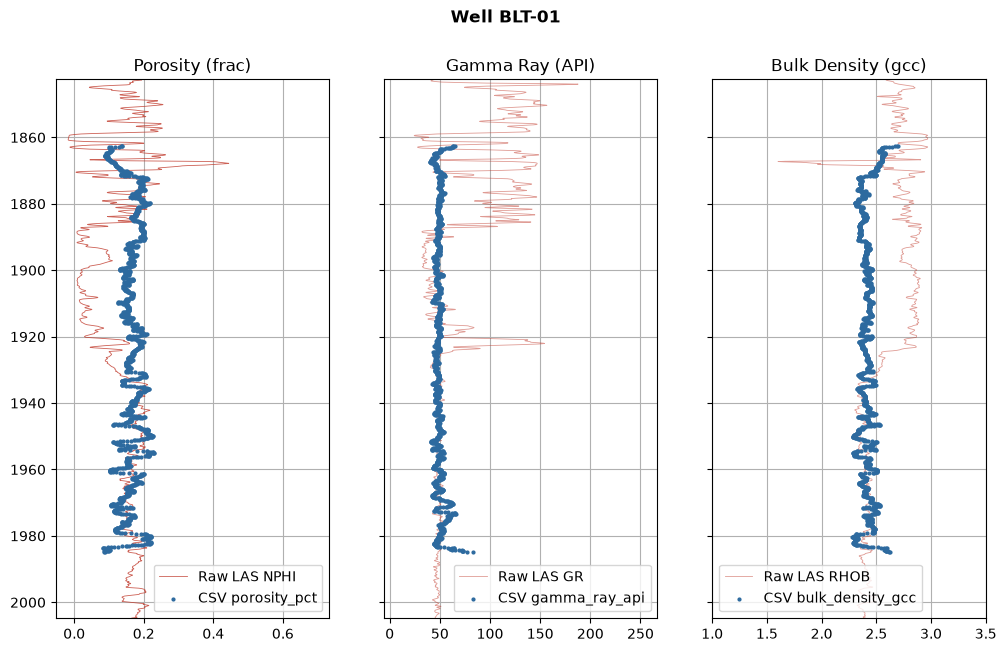

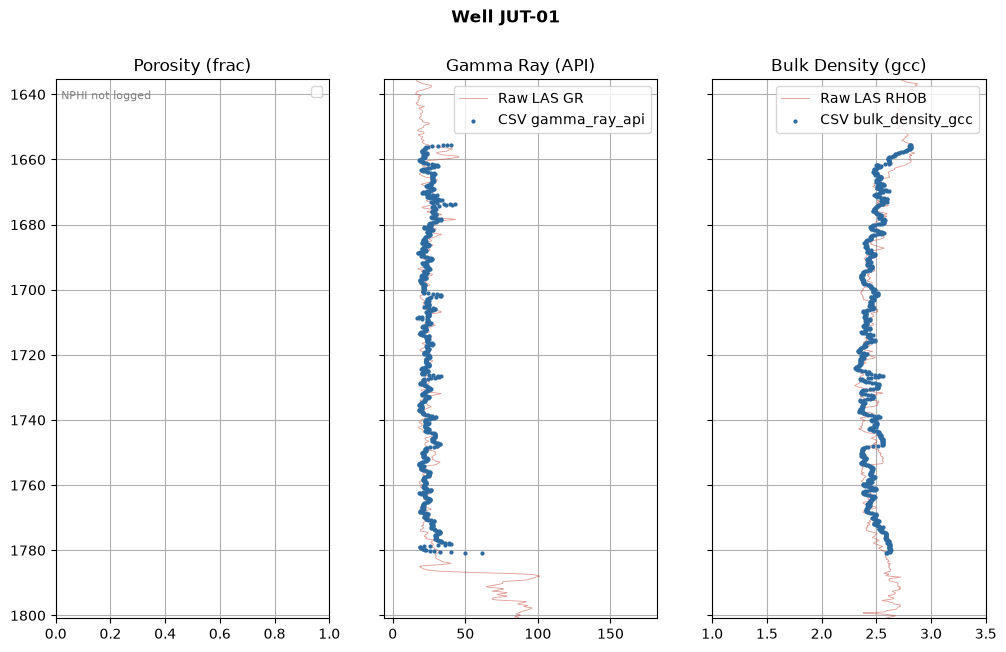

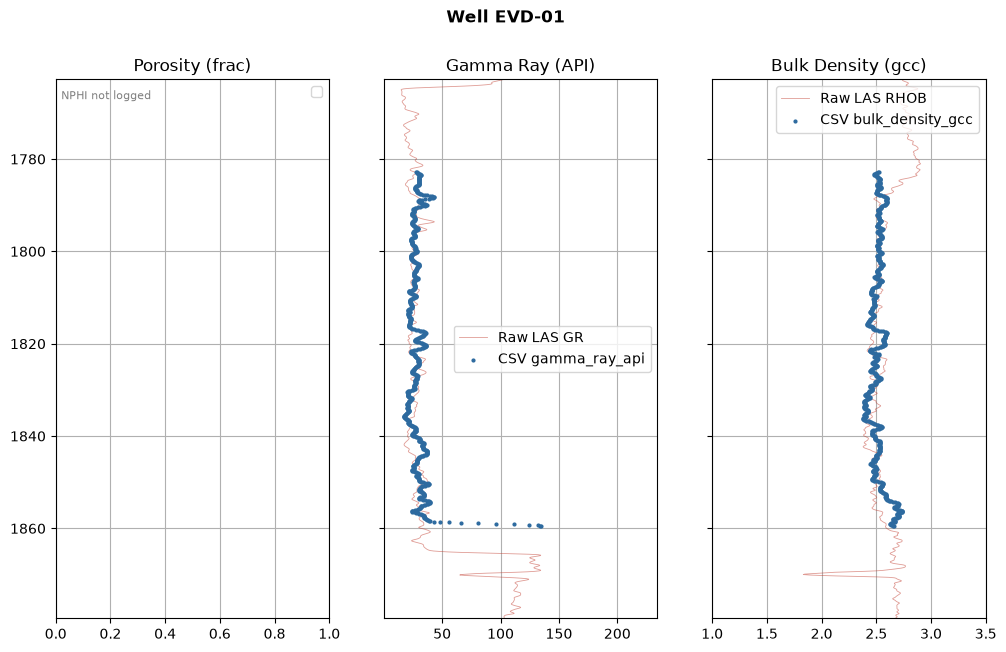

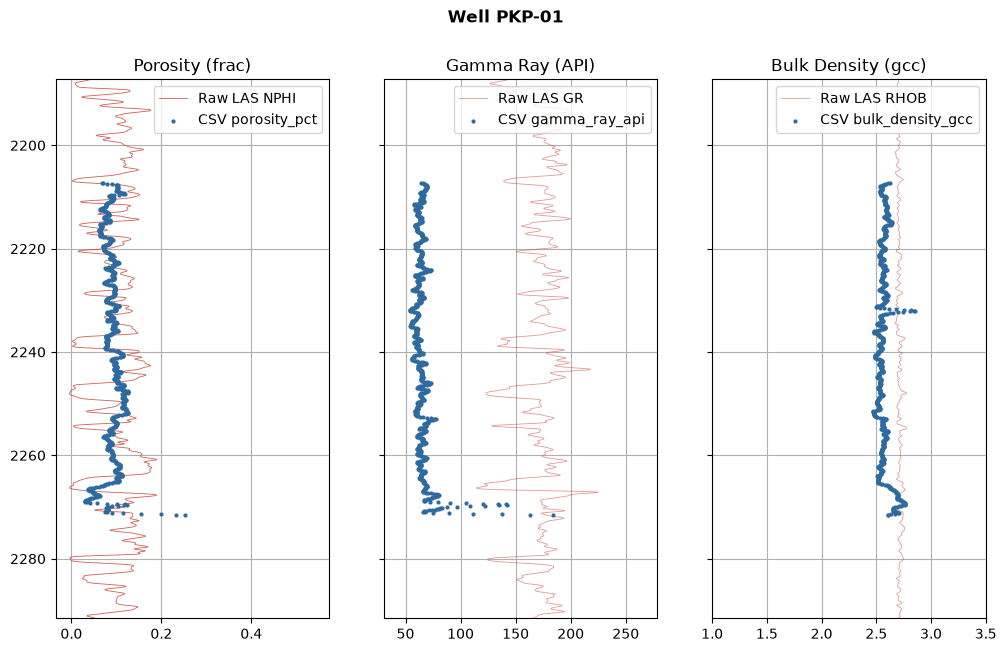

In [14]:
for well in well_names:
    well_log = dfs_las[well]
    csv_rows =df[df["well_id"] == well].reset_index()

    depth_col = "MD_m"

    has_nphi = "NPHI" in well_log.columns

    fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey = True)
    fig.suptitle(f"Well {well}", fontsize=12, fontweight="bold")
    if has_nphi:
        axes[0].plot(well_log["NPHI"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.8, label="Raw LAS NPHI")
        axes[0].scatter(csv_rows["porosity_pct"]/100, csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV porosity_pct")
    else:
        axes[0].text(0.02, 0.98, "NPHI not logged", transform=axes[0].transAxes, va="top", fontsize=8, color="gray")
    axes[0].set_title("Porosity (frac)")

    axes[1].plot(well_log["GR"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS GR")
    axes[1].scatter(csv_rows["gamma_ray_api"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV gamma_ray_api")
    axes[1].set_title("Gamma Ray (API)")

    axes[2].plot(well_log["RHOB"], well_log[depth_col], color="#c0392b", linewidth=0.6, alpha=0.5, label="Raw LAS RHOB")
    axes[2].scatter(csv_rows["bulk_density_gcc"], csv_rows["depth_tvd_m"], color="#2d6a9f", s=4, zorder=5, label="CSV bulk_density_gcc")
    axes[2].set_xlim(1.0, 3.5)
    axes[2].set_title("Bulk Density (gcc)")

    for ax in axes:
        ax.set_ylim(csv_rows["depth_tvd_m"].max() + 20, csv_rows["depth_tvd_m"].min() - 20)
        ax.grid()
        ax.legend()

## Checking empty rows

In [15]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing depth_tvd_m rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing porosity_pct rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing bulk_density_gcc rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


No missing depth_tvd_m rows

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    836
dtype: int64

No missing bulk_density_gcc rows


## Filling in 'porosity_pct'

### 'Bulk Density' vs 'Porosity' CrossPlot

Well PKP-01 correlation coefficient: -0.472
Well BLT-01 correlation coefficient: -0.949


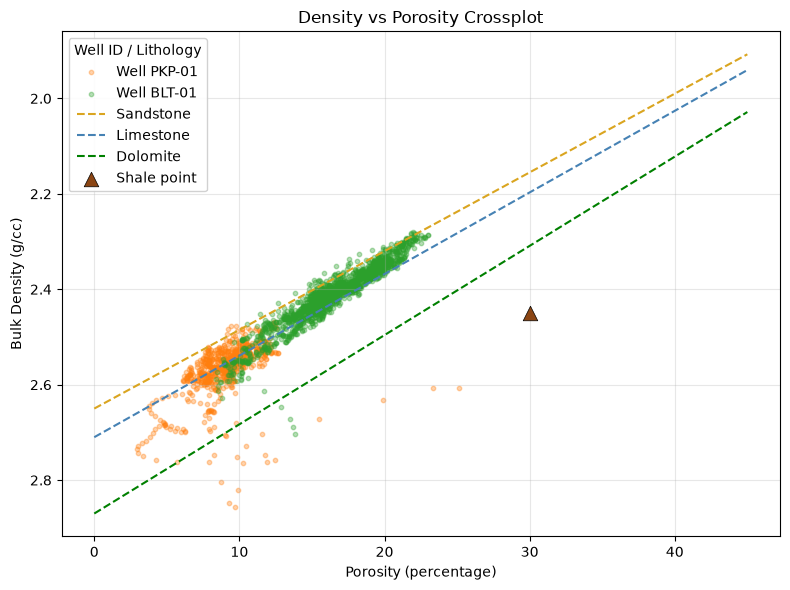

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cm.tab10.colors

for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["bulk_density_gcc"].notna().any() and well_df["porosity_pct"].notna().any():
        ax.scatter(
            well_df["porosity_pct"],
            well_df["bulk_density_gcc"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["bulk_density_gcc"].corr(well_df["porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")

rho_fl = 1.0

lithology_lines = {
    "Sandstone": {"rho_ma": 2.65, "style": "--", "color": "goldenrod"},
    "Limestone": {"rho_ma": 2.71, "style": "--", "color": "steelblue"},
    "Dolomite" : {"rho_ma": 2.87, "style": "--", "color": "green"},
}

phi_line = np.array([0, 45])
for name, props in lithology_lines.items():
    rho_b_line = props["rho_ma"] - (phi_line / 100.0) * (props["rho_ma"] - rho_fl)
    ax.plot(phi_line, rho_b_line, linestyle=props["style"], color=props["color"],
             linewidth=1.5, label= name, zorder=4)

shale_density = 2.45
shale_porosity = 30
ax.scatter(shale_porosity, shale_density, marker="^", s=110, color="saddlebrown",
           edgecolor="black", linewidth=0.5, label="Shale point", zorder=5)

ax.set_xlabel("Porosity (percentage)")
ax.set_ylabel("Bulk Density (g/cc)")
ax.set_title("Density vs Porosity Crossplot")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
ax.legend(title="Well ID / Lithology", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

$$\text{Porosity - Density Equation}$$
$$\phi = \frac{\rho_{ma} - \rho_b}{\rho_{ma} - \rho_{fl}} \times 100$$

In [17]:
implied_rho_ma = {"BLT-01" : 2.68, "PKP-01" : 2.71}
RHO_FL = 1.07

for well, rho_ma in implied_rho_ma.items():
    mask = df["well_id"] == well
    df.loc[mask, "rhob_porosity_pct"] = (
        ((rho_ma - df.loc[mask, "bulk_density_gcc"]) / (rho_ma - RHO_FL))
        .clip(0.02, 1.0)
        * 100
    )

### DT log

In [18]:
df["sonic_us_ft"] = np.nan

for well in well_list:
    las = dfs_las[well]  
    depth_col = "MD_m"
    dt_col = "DTC"

    mask = df["well_id"] == well
    formation_top = df.loc[mask, "formation_top_tvd"].iloc[0]
    formation_base = df.loc[mask, "formation_base_tvd"].iloc[0]

    subset = las[(las[depth_col] >= formation_top) & (las[depth_col] <= formation_base)]
    subset = subset.dropna(subset=["GR", dt_col])

    merged = df[mask].reset_index().merge(
        subset[["GR", dt_col]].rename(columns={"GR": "gamma_ray_api", dt_col: "sonic_us_ft_new"}),
        on="gamma_ray_api", how="left"
    ).drop_duplicates(subset="index").set_index("index")

    n_matched = merged["sonic_us_ft_new"].notna().sum()
    print(f"{well}: {n_matched} / {mask.sum()} sonic log rows matched")

    df.loc[merged.index, "sonic_us_ft"] = merged["sonic_us_ft_new"]

EVD-01: 780 / 780 sonic log rows matched
PKP-01: 730 / 730 sonic log rows matched
BLT-01: 1689 / 1689 sonic log rows matched
JUT-01: 836 / 836 sonic log rows matched


### RHOB vs DT Crossplot

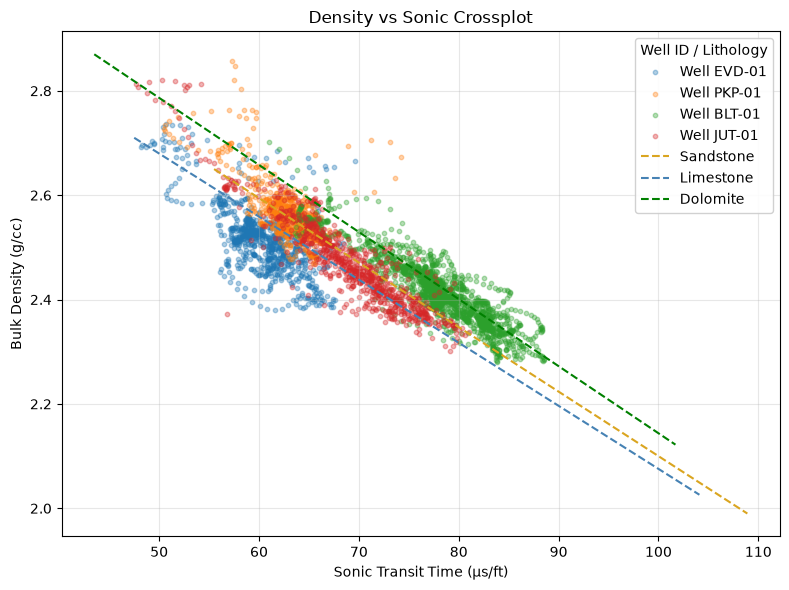

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["sonic_us_ft"].notna().any() and well_df["bulk_density_gcc"].notna().any():
        ax.scatter(
            well_df["sonic_us_ft"],
            well_df["bulk_density_gcc"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )

# --- Lithology lines using Wyllie time-average + density equations ---
# matrix transit times (us/ft) and matrix densities (g/cc) for common lithologies
lithologies = {
    "Sandstone": {"dt_ma": 55.5, "rho_ma": 2.65, "color": "goldenrod"},
    "Limestone": {"dt_ma": 47.5, "rho_ma": 2.71, "color": "steelblue"},
    "Dolomite":  {"dt_ma": 43.5, "rho_ma": 2.87, "color": "green"},
}
dt_fl, rho_fl = 189, 1.0  # fluid transit time (us/ft) and density (g/cc)

phi = np.linspace(0, 0.40, 50)  # fractional porosity, 0-40%
for name, props in lithologies.items():
    dt_line = phi * dt_fl + (1 - phi) * props["dt_ma"]
    rho_line = props["rho_ma"] - phi * (props["rho_ma"] - rho_fl)
    ax.plot(dt_line, rho_line, linestyle="--", color=props["color"], label=name, zorder=4)

ax.set_xlabel("Sonic Transit Time (µs/ft)")
ax.set_ylabel("Bulk Density (g/cc)")
ax.set_title("Density vs Sonic Crossplot")
ax.grid(True, alpha=0.3)
ax.legend(title="Well ID / Lithology", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

$$\text{Wyllie Time-Average Equation}$$
$$\phi_{\text{sonic}} = \frac{DT_{\text{log}} - DT_{\text{ma}}}{DT_{\text{fl}} - DT_{\text{ma}}} \times 100$$

In [20]:
implied_dt_ma = {"BLT-01" : 55, "JUT-01" : 50, "EVD-01" : 50, "PKP-01" : 55} 
DT_FL = 190

for well, dt_ma in implied_dt_ma.items():
    mask = df["well_id"] == well
    df.loc[mask, "sonic_porosity_pct"] = (
        ((df.loc[mask, "sonic_us_ft"] - dt_ma) / (DT_FL - dt_ma))
        .clip(0.02, 1.0)
        * 100
    )

### Correlation

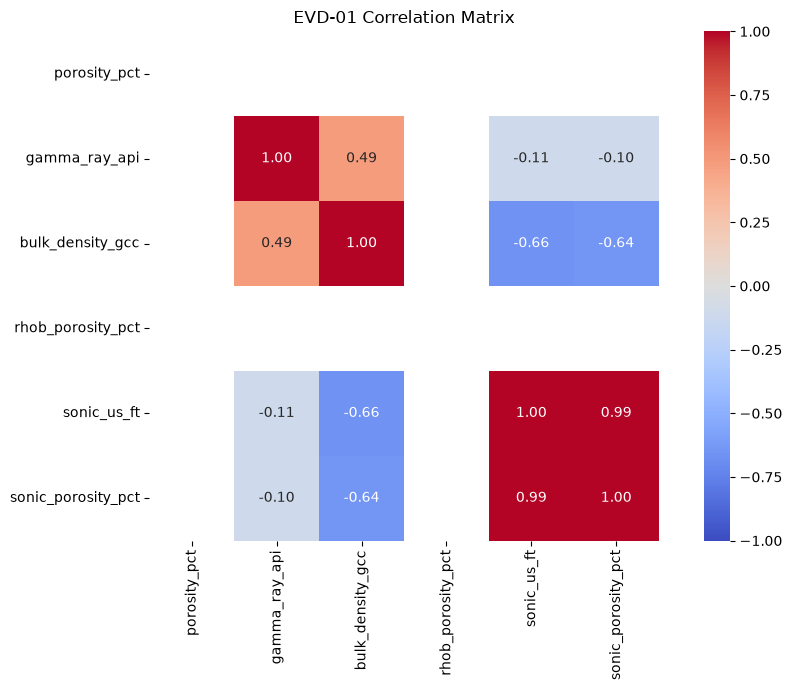

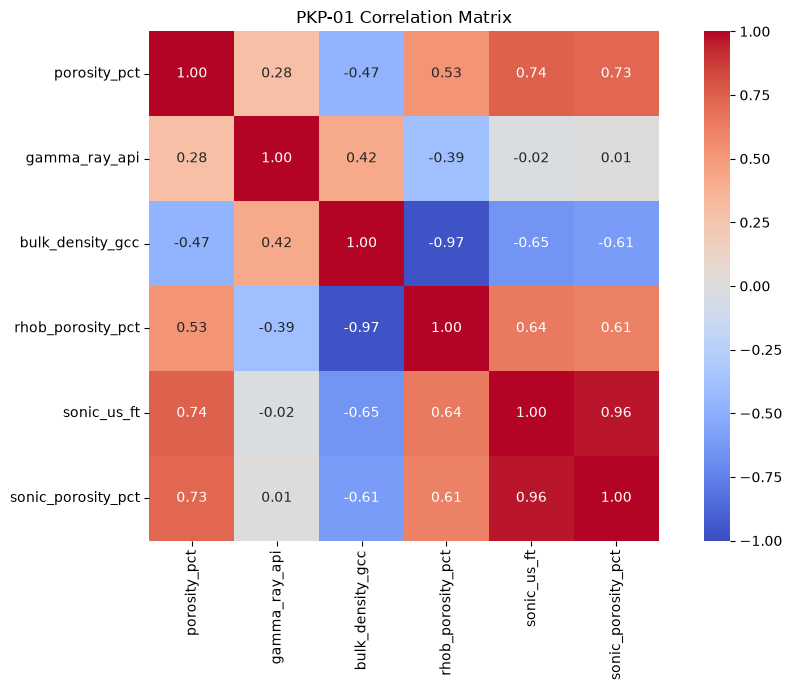

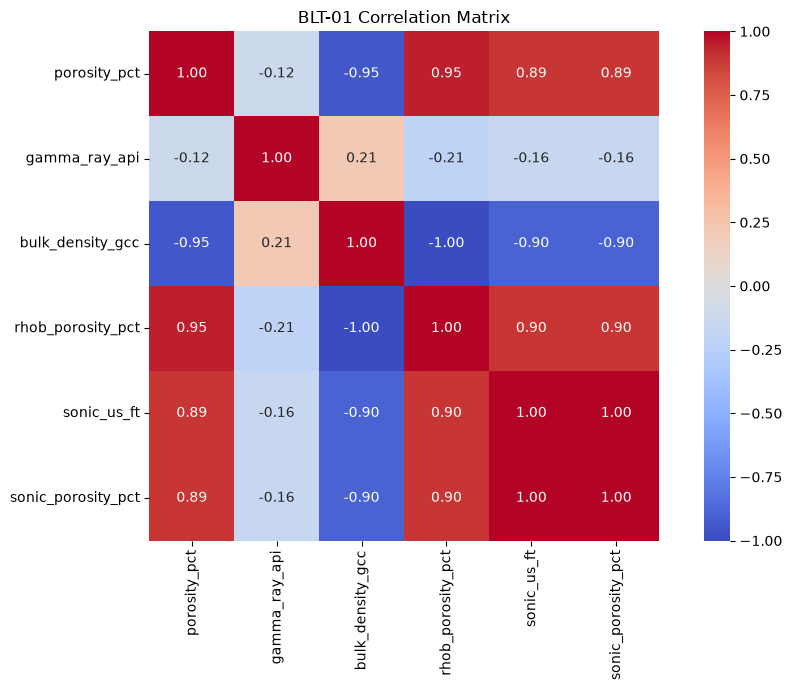

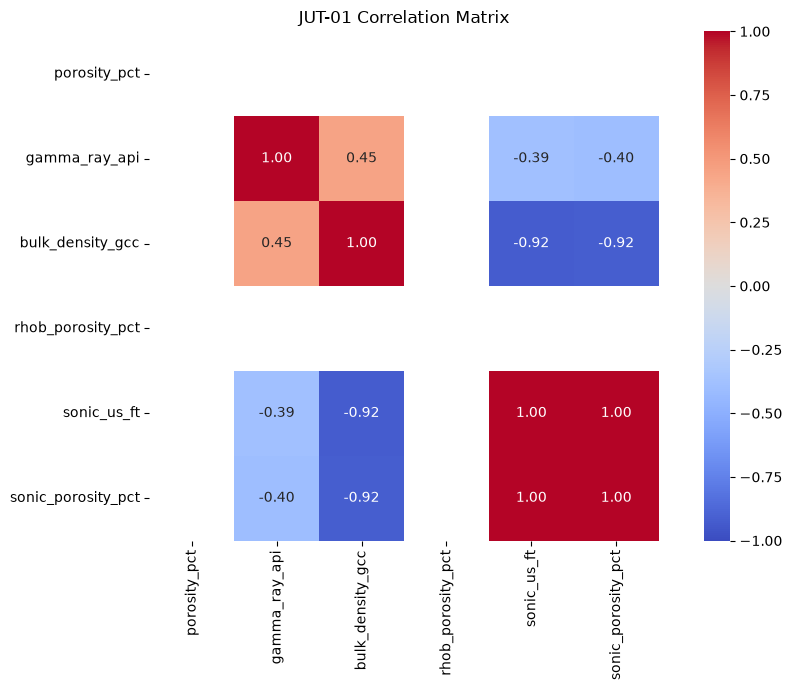

In [21]:
# Correlation heatmaps
for well in well_list:
    tot_cols = log_cols + ["rhob_porosity_pct"] + ["sonic_us_ft"] + ["sonic_porosity_pct"]

    corr = df[df["well_id"] == well][tot_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm', vmin=-1, vmax=1, square=True)
    ax.set_title(f'{well} Correlation Matrix')

    plt.tight_layout()

### Feature Selection

In [22]:
FEATURES = ["bulk_density_gcc", "sonic_us_ft"]
TARGET = "porosity_pct"

model_df = df.dropna(subset=FEATURES + [TARGET]).copy()

### Leave-one-well-out Cross-validation

In [23]:
def make_models():
    return {
        "median_by_well": None,
        "rhob_por": None,
        "sonic_por": None,
        "linear_regression": LinearRegression(),
        "random_forest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
        "gradient_boosting": XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.03, random_state=42),
    }

In [24]:
implied_rho_ma = {"BLT-01": 2.68, "PKP-01": 2.71, "JUT-01": 2.68, "EVD-01": 2.71}
implied_dt_ma  = {"BLT-01": 55,   "PKP-01": 55,   "JUT-01": 50,   "EVD-01": 50}

def lowo_cv(df, target, wells):
    df = df[df.well_id.isin(wells) & df[target].notna()].reset_index(drop=True)
    
    rows = []

    for test_well in wells:
        train_df = df[df.well_id != test_well]
        test_df = df[df.well_id == test_well]

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        X_train, y_train = train_df[FEATURES], train_df[target]
        X_test, y_test = test_df[FEATURES], test_df[target]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- leave-one-out: average the OTHER wells' assumed matrix values ---
        other_rho_ma = [v for w, v in implied_rho_ma.items() if w != test_well and w in wells]
        other_dt_ma  = [v for w, v in implied_dt_ma.items()  if w != test_well and w in wells]
        rho_ma_est = np.mean(other_rho_ma) if other_rho_ma else None
        dt_ma_est  = np.mean(other_dt_ma)  if other_dt_ma  else None

        methods = make_models()

        for name, model in methods.items():
            if name == "median_by_well":
                overall_median = train_df[target].median()
                pred = np.full(shape=len(test_df), fill_value=overall_median)
            elif name == "rhob_por":
                if rho_ma_est is None:
                    pred = np.full(len(test_df), np.nan)
                else:
                    pred = (((rho_ma_est - test_df['bulk_density_gcc']) / (rho_ma_est - RHO_FL))
                            .clip(0.02, 1.0) * 100)
            elif name == "sonic_por":
                if dt_ma_est is None:
                    pred = np.full(len(test_df), np.nan)
                else:
                    pred = (((test_df["sonic_us_ft"] - dt_ma_est) / (DT_FL - dt_ma_est))
                            .clip(0.02, 1.0) * 100)
            else:
                model.fit(X_train_scaled, y_train)
                pred = model.predict(X_test_scaled)
            rows.append({
                "target": target, "method": name, "test_well": test_well,
                "n": len(y_test),
                "MAE": mean_absolute_error(y_test, pred),
                "RMSE": mean_squared_error(y_test, pred) ** 0.5,
                "bias": float(np.mean(pred - y_test)),
                "R2": r2_score(y_test, pred) if len(y_test) > 1 else np.nan,
            })
    
    report = pd.DataFrame(rows)
    
    return report

In [25]:
lowo_cv(model_df, TARGET, well_list)

,target,method,test_well,n,MAE,RMSE,bias,R2
0,porosity_pct,median_by_well,PKP-01,730,7.367129,7.569104,7.314207,-14.101653
1,porosity_pct,rhob_por,PKP-01,730,1.656244,2.525570,-1.136981,-0.681336
2,porosity_pct,sonic_por,PKP-01,730,1.229066,1.631834,-0.879904,0.298080
3,porosity_pct,linear_regression,PKP-01,730,1.161933,2.020645,-0.116897,-0.076256
4,porosity_pct,random_forest,PKP-01,730,1.963402,2.638893,1.706554,-0.835604
5,porosity_pct,gradient_boosting,PKP-01,730,2.094024,2.594670,1.907413,-0.774598
6,porosity_pct,median_by_well,BLT-01,1689,7.228149,7.805526,-7.221548,-5.942786
7,porosity_pct,rhob_por,BLT-01,1689,1.537763,1.833374,1.227962,0.616971
8,porosity_pct,sonic_por,BLT-01,1689,2.930817,3.237266,2.810457,-0.194225
9,porosity_pct,linear_regression,BLT-01,1689,1.185091,1.565468,0.763341,0.720734


### JUT-01 and EVD-01 porosities

In [26]:
train_wells = ["PKP-01", "BLT-01"]
train_df = df[df.well_id.isin(train_wells) & df["porosity_pct"].notna()]

X_train, y_train = train_df[FEATURES], train_df["porosity_pct"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train)

for target_well in ["EVD-01", "JUT-01"]:
    mask = df.well_id == target_well
    X_new = df.loc[mask, FEATURES]
    X_new_scaled = scaler.transform(X_new)
    df.loc[mask, "porosity_pct"] = final_model.predict(X_new_scaled)

In [27]:
df.groupby("well_id")[["bulk_density_gcc", "gamma_ray_api", "porosity_pct", "rhob_porosity_pct", "sonic_porosity_pct"]].mean()

,bulk_density_gcc,gamma_ray_api,porosity_pct,rhob_porosity_pct,sonic_porosity_pct
well_id,,,,,
BLT-01,2.413076,48.996611,16.376898,16.583481,17.191981
EVD-01,2.514221,28.501493,9.122784,NaN,7.365634
JUT-01,2.470648,24.318875,12.574300,NaN,13.603656
PKP-01,2.566157,64.993401,9.041593,8.947479,5.956465


In [28]:
df_filled = df[["well_id", "easting", "northing", "depth_tvd_m", "porosity_pct", "gamma_ray_api", "bulk_density_gcc", "formation_thickness_m"]].copy()
df_filled.info()

<class 'pandas.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                4035 non-null   str    
 1   easting                4035 non-null   float64
 2   northing               4035 non-null   float64
 3   depth_tvd_m            4035 non-null   float64
 4   porosity_pct           4035 non-null   float64
 5   gamma_ray_api          4035 non-null   float64
 6   bulk_density_gcc       4035 non-null   float64
 7   formation_thickness_m  4035 non-null   float64
dtypes: float64(7), str(1)
memory usage: 252.3 KB


In [29]:
df_filled.to_csv(PROCESSED / "target_lithologies_filled.csv", index=False)